In [1]:
# import torch
# from keras.src.tree import flatten
# from sympy.codegen.ast import none
# from torch.utils import bottleneck
#
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
from torch import nn
import torch

class UNet(nn.Module):
    def __init__(self, in_channels, classifier_hidden = 256, num_classes=4, features = [64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        self.final_conv = nn.Conv2d(features[0], 1, kernel_size = 1)
        self.bottleneck = self._double_conv(features[-1], features[-1]*2)
        self.classifier_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(features[-1]*2, classifier_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(classifier_hidden, num_classes)
        )

        for feature in features:
            self.downs.append(self._double_conv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(self._double_conv(feature*2, feature))

    def _double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = 1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # print("Input:", x.shape)

        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        pooled_output = self.classifier_pool(x)
        flattened_output = torch.flatten(pooled_output, start_dim=1)
        logits = self.classifier(flattened_output)

        # print("After bottleneck:", x.shape)

        skip_connections = skip_connections[::-1] # reversing the list cause we will be needing the last skip connection first

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            x = torch.cat([skip_connection, x], dim=1)
            x = self.ups[idx + 1](x)

        mask_pred = self.final_conv(x)

        return mask_pred, logits

In [3]:
x = torch.randn(1, 1, 256, 256)

model = UNet(in_channels=1)

mask, logits = model(x)

print(mask.shape)
print(logits.shape)

Input: torch.Size([1, 1, 256, 256])
After bottleneck: torch.Size([1, 1024, 16, 16])
torch.Size([1, 1, 256, 256])
torch.Size([1, 4])


In [4]:
from torchinfo import summary

summary(
    model,
    input_size=(1,1,256,256),
    col_names=[
        "input_size",
        "output_size",
        "num_params"
    ]
)

Input: torch.Size([1, 1, 256, 256])
After bottleneck: torch.Size([1, 1024, 16, 16])


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
UNet                                     [1, 1, 256, 256]          [1, 1, 256, 256]          --
├─ModuleList: 1-7                        --                        --                        (recursive)
│    └─Sequential: 2-1                   [1, 1, 256, 256]          [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 1, 256, 256]          [1, 64, 256, 256]         640
│    │    └─ReLU: 3-2                    [1, 64, 256, 256]         [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-3                  [1, 64, 256, 256]         [1, 64, 256, 256]         36,928
│    │    └─ReLU: 3-4                    [1, 64, 256, 256]         [1, 64, 256, 256]         --
├─MaxPool2d: 1-2                         [1, 64, 256, 256]         [1, 64, 128, 128]         --
├─ModuleList: 1-7                        --                        --                        (recursive)
│    └─Seque

In [5]:
import os
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import torch

class BrainTumorDataset(Dataset):

    def __init__(self, segmentation_root_dir, classification_root_dir, split="Training", transform=None, img_size=256):

        self.img_size = img_size
        self.transform = transform
        self.class_to_idx = {"glioma": 0, "meningioma": 1, "pituitary": 2, "notumor": 3}
        self.samples =[]

        seg_folder_to_class = {
            "Glioma": "glioma",
            "Meningioma": "meningioma",
            "Pituitary tumor": "pituitary",
        }

        for folder_name, class_name in seg_folder_to_class.items():
            folder_path = os.path.join(segmentation_root_dir, folder_name)
            class_idx = self.class_to_idx[class_name]

            for fname in os.listdir(folder_path):

                if "_mask.png" in fname:
                    continue

                if not fname.endswith((".png", ".jpg", ".jpeg")):
                    continue

                img_path = os.path.join(folder_path, fname)
                stem = os.path.splitext(fname)[0]
                mask_name = f"{stem}_mask.png"
                mask_path = os.path.join(folder_path, mask_name)

                if not os.path.exists(mask_path):
                    continue

                self.samples.append((img_path, mask_path, class_idx))


        no_tumor_path = os.path.join(classification_root_dir, split, "notumor")
        notumor_idx = self.class_to_idx["notumor"]
        for fname in os.listdir(no_tumor_path):

            if not fname.endswith((".png", ".jpg", ".jpeg")):
                    continue

            img_path = os.path.join(no_tumor_path, fname)

            self.samples.append((img_path, None, notumor_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, class_idx = self.samples[idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if mask_path is not None:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.float32)

        else:
            h, w = img.shape[:2]
            mask = np.zeros((h, w), dtype=np.float32)

        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask)

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        class_label = torch.tensor(class_idx, dtype=torch.long)

        return img, mask, class_label


In [6]:
train_transform = A.Compose([
    A.Resize(256, 256),                  # uniform size — required for batching
    A.HorizontalFlip(p=0.5),             # anatomically plausible for axial MRI slices
    A.Rotate(limit=15, p=0.5),           # small rotation — real scan angle varies slightly
    A.RandomBrightnessContrast(p=0.3),   # simulates scanner/exposure variation
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),  # scale to roughly [-1, 1]
    ToTensorV2(),                        # converts numpy HWC -> torch CHW tensor
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])

In [7]:
train_dataset = BrainTumorDataset(
    segmentation_root_dir="tumor_dataset/DATASET/Segmentation",
    classification_root_dir="tumor_dataset/DATASET/classification",
    split="Training",
    transform=train_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    # num_workers=0, bugs out in windows especially in Jupyter notebook
    pin_memory=True,
    drop_last=True,
)

In [8]:
print(len(train_dataset))

3787


In [9]:
img, mask, label = train_dataset[0]

print(img.shape)
print(mask.shape)
print(label)
print(img.dtype)
print(mask.dtype)

torch.Size([1, 256, 256])
torch.Size([1, 256, 256])
tensor(0)
torch.float32
torch.float32


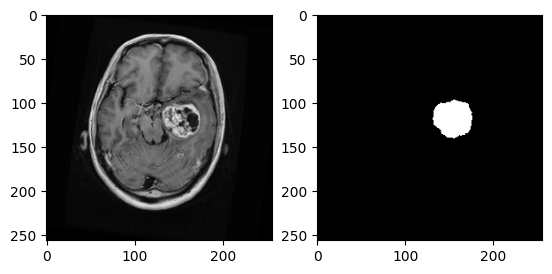

In [10]:
import matplotlib.pyplot as plt

img, mask, label = train_dataset[0]

plt.subplot(1,2,1)
plt.imshow(img.squeeze(0), cmap="gray")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(0), cmap="gray")

plt.show()

In [11]:
images, masks, labels = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(labels.shape)

torch.Size([16, 1, 256, 256])
torch.Size([16, 1, 256, 256])
torch.Size([16])


In [12]:
model = UNet(
    in_channels=1,
    num_classes=4
)

In [13]:
mask_pred, logits = model(images)

print(mask_pred.shape)
print(logits.shape)

Input: torch.Size([16, 1, 256, 256])
After bottleneck: torch.Size([16, 1024, 16, 16])
torch.Size([16, 1, 256, 256])
torch.Size([16, 4])


In [14]:
seg_criterion = nn.BCEWithLogitsLoss()
cls_criterion = nn.CrossEntropyLoss()

In [15]:
seg_loss = seg_criterion(
    mask_pred,
    masks.float()
)

cls_loss = cls_criterion(
    logits,
    labels
)

loss = seg_loss + cls_loss

In [17]:
print(seg_loss.item())
print(cls_loss.item())
print(loss.item())

0.6494578123092651
1.3829585313796997
2.032416343688965
